<a href="https://colab.research.google.com/github/dressasys/TechChallenge3_Grupo87_PosTech/blob/main/Inteligencia_Hospitalar_Andressa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração global de estilo
sns.set_theme(style="whitegrid")

# =====================================================================
# GERANDO DADOS FICTÍCIOS CORRIGIDOS (Simulando a Camada Gold)
# =====================================================================
dados_risco = {
    'nome_mes': ['Setembro']*9 + ['Outubro']*9 + ['Novembro']*9,
    'polo_epidemiologico': ['Capital', 'Região Metropolitana', 'Interior'] * 9,
    'faixa_etaria': (['0-18', '19-30', '31-50', '51-65', '65+'] * 6)[:27],
    'desc_dificuldade_respirar': ['Sim', 'Não', 'Sim'] * 9,
    'total_pacientes_estimados': np.random.randint(50, 2000, size=27)
}
df_risco = pd.DataFrame(dados_risco)

# Simulando a onda
df_risco.loc[(df_risco['nome_mes'] == 'Outubro') & (df_risco['polo_epidemiologico'] == 'Capital'), 'total_pacientes_estimados'] *= 2.5
df_risco.loc[(df_risco['nome_mes'] == 'Novembro') & (df_risco['polo_epidemiologico'] == 'Interior'), 'total_pacientes_estimados'] *= 2.0

dados_vuln = {
    'polo_epidemiologico': ['Capital', 'Capital', 'Região Metropolitana', 'Região Metropolitana', 'Interior', 'Interior'],
    'desc_trabalho_remoto': ['Sim', 'Não', 'Sim', 'Não', 'Sim', 'Não'],
    'total_populacao': [50000, 150000, 20000, 250000, 30000, 180000]
}
df_vuln = pd.DataFrame(dados_vuln)

# Base já filtrada para pacientes com sintomas graves
df_graves = df_risco[df_risco['desc_dificuldade_respirar'] == 'Sim']

print("Base de dados gerada com sucesso! Pronta para visualização.")

Base de dados gerada com sucesso! Pronta para visualização.


/tmp/ipykernel_56606/4199387492.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3712.5 2290.  4320. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_risco.loc[(df_risco['nome_mes'] == 'Outubro') & (df_risco['polo_epidemiologico'] == 'Capital'), 'total_pacientes_estimados'] *= 2.5


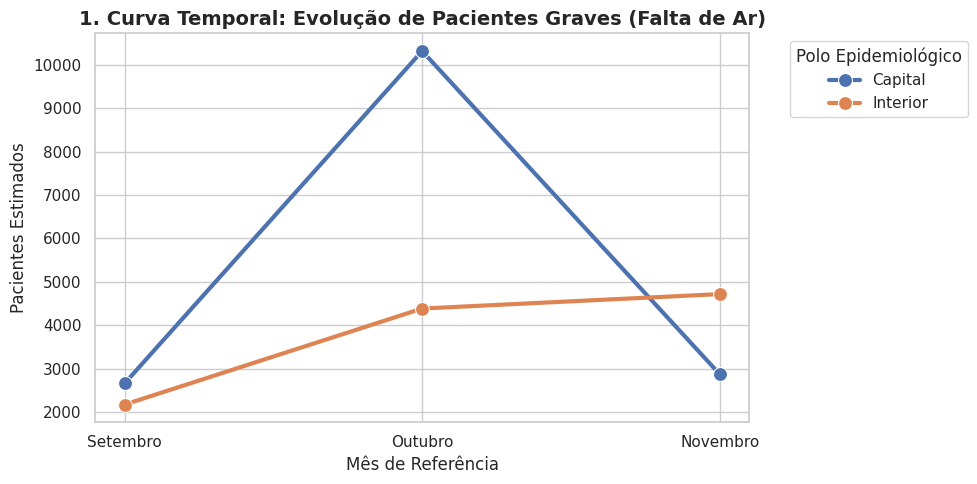

In [ ]:
# ---------------------------------------------------------------------
# GRÁFICO 1: Curva Temporal (Evolução de Casos Graves)
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 5)) # Tamanho individual perfeito para a tela

grafico_linha = df_graves.groupby(['nome_mes', 'polo_epidemiologico'])['total_pacientes_estimados'].sum().reset_index()
meses_ordem = ['Setembro', 'Outubro', 'Novembro']
grafico_linha['nome_mes'] = pd.Categorical(grafico_linha['nome_mes'], categories=meses_ordem, ordered=True)

sns.lineplot(data=grafico_linha, x='nome_mes', y='total_pacientes_estimados',
             hue='polo_epidemiologico', marker='o', linewidth=3, markersize=10)

plt.title('1. Curva Temporal: Evolução de Pacientes Graves (Falta de Ar)', fontsize=14, fontweight='bold')
plt.ylabel('Pacientes Estimados')
plt.xlabel('Mês de Referência')
plt.legend(title='Polo Epidemiológico', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

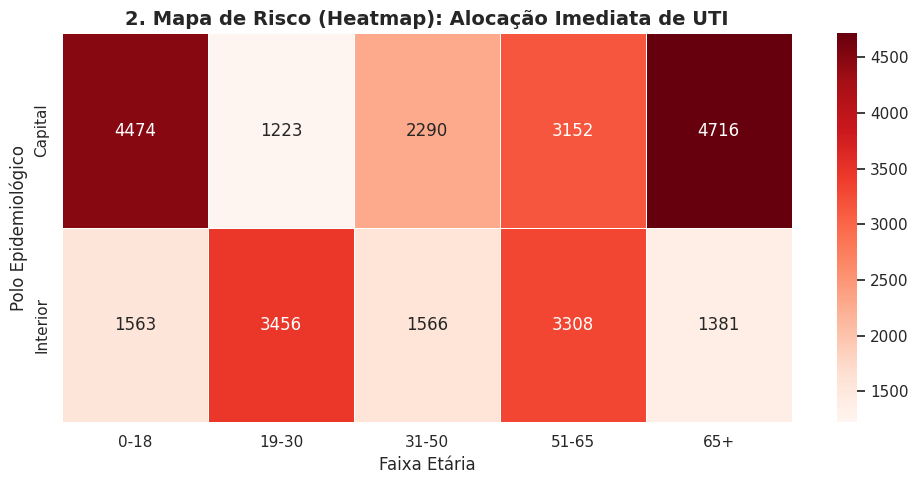

In [ ]:
# ---------------------------------------------------------------------
# GRÁFICO 2: Mapa de Calor (Risco Clínico Atual por Idade e Polo)
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 5))

heatmap_data = df_graves.groupby(['polo_epidemiologico', 'faixa_etaria'])['total_pacientes_estimados'].sum().unstack().fillna(0)

sns.heatmap(data=heatmap_data, annot=True, fmt=".0f", cmap="Reds", linewidths=.5)
plt.title('2. Mapa de Risco (Heatmap): Alocação Imediata de UTI', fontsize=14, fontweight='bold')
plt.ylabel('Polo Epidemiológico')
plt.xlabel('Faixa Etária')
plt.tight_layout()
plt.show()

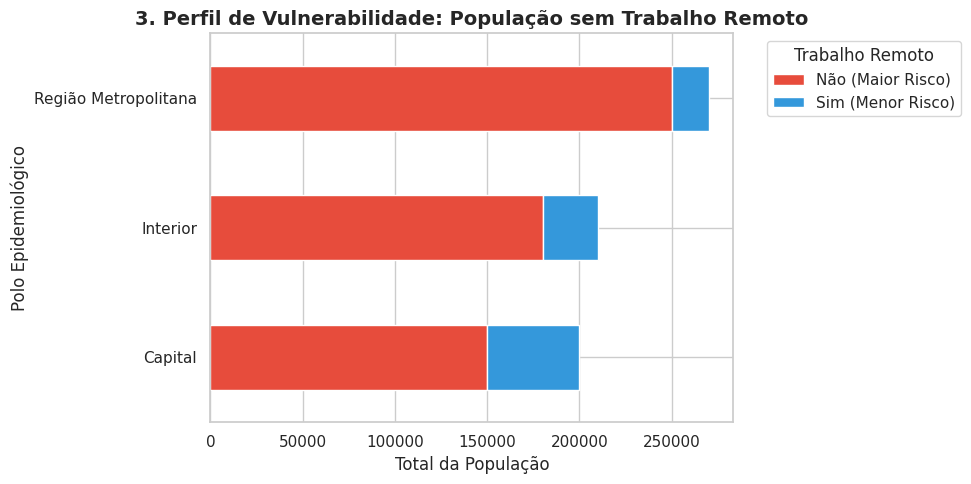

In [ ]:
# ---------------------------------------------------------------------
# GRÁFICO 3: Perfil de Vulnerabilidade (Trabalho Remoto)
# ---------------------------------------------------------------------
bar_data = df_vuln.pivot(index='polo_epidemiologico', columns='desc_trabalho_remoto', values='total_populacao')

# O Pandas já cria a figure automaticamente quando usamos .plot
ax = bar_data.plot(kind='barh', stacked=True, color=['#e74c3c', '#3498db'], figsize=(10, 5))

plt.title('3. Perfil de Vulnerabilidade: População sem Trabalho Remoto', fontsize=14, fontweight='bold')
plt.xlabel('Total da População')
plt.ylabel('Polo Epidemiológico')
plt.legend(title='Trabalho Remoto', labels=['Não (Maior Risco)', 'Sim (Menor Risco)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração global de estilo
sns.set_theme(style="whitegrid")

# =====================================================================
# 1. GERANDO DADOS FICTÍCIOS (Simulando a nova tabela Gold_Perfil_Sintomas)
# =====================================================================
np.random.seed(42)
n_pacientes = 1000

dados_sintomas = {
    'faixa_etaria': np.random.choice(['0-18', '19-30', '31-50', '51-65', '65+'], n_pacientes),
    'teve_febre': np.random.choice(['Sim', 'Não'], n_pacientes, p=[0.4, 0.6]),
    'teve_tosse': np.random.choice(['Sim', 'Não'], n_pacientes, p=[0.6, 0.4]),
    'dificuldade_respirar': np.random.choice(['Sim', 'Não'], n_pacientes, p=[0.15, 0.85]),
    'perda_cheiro_sabor': np.random.choice(['Sim', 'Não'], n_pacientes, p=[0.3, 0.7]),
    'pacientes_estimados': np.random.randint(10, 100, size=n_pacientes) # Peso amostral
}
df_base = pd.DataFrame(dados_sintomas)

# Forçando uma lógica clínica fictícia para o gráfico ficar interessante:
# Idosos têm muito mais "Falta de Ar" do que os jovens.
df_base.loc[df_base['faixa_etaria'] == '65+', 'dificuldade_respirar'] = np.random.choice(
    ['Sim', 'Não'], len(df_base[df_base['faixa_etaria'] == '65+']), p=[0.55, 0.45]
)

print("Base de sintomas gerada com sucesso! Variáveis criadas.")

Base de sintomas gerada com sucesso! Variáveis criadas.


/tmp/ipykernel_56606/3568735470.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_prev, x='Total Estimado', y='Sintoma', palette='viridis')


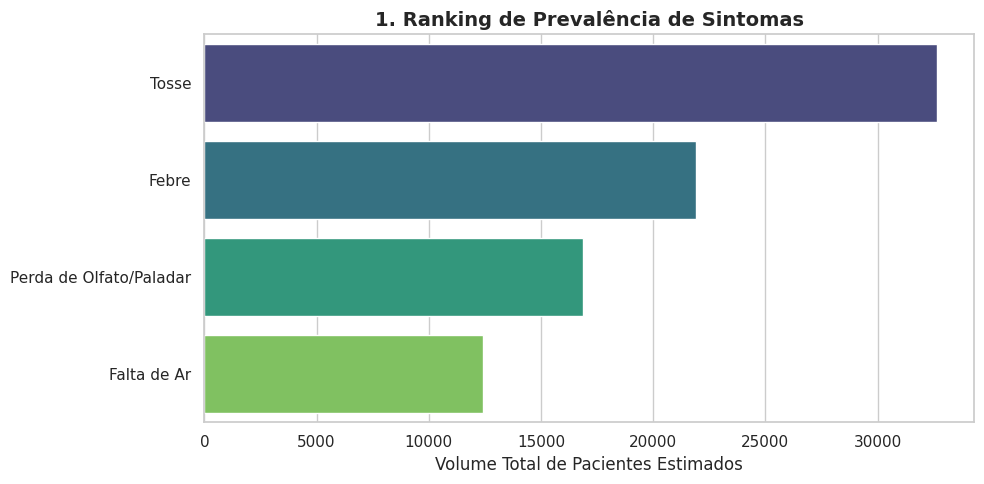

In [ ]:
# ---------------------------------------------------------------------
# GRÁFICO 1: Ranking de Prevalência Absoluta
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 5))

sintomas_cols = ['teve_febre', 'teve_tosse', 'dificuldade_respirar', 'perda_cheiro_sabor']
nomes_bonitos = ['Febre', 'Tosse', 'Falta de Ar', 'Perda de Olfato/Paladar']

# Somando os pesos apenas onde a resposta foi 'Sim'
prevalencia = []
for col, nome in zip(sintomas_cols, nomes_bonitos):
    total_sim = df_base[df_base[col] == 'Sim']['pacientes_estimados'].sum()
    prevalencia.append({'Sintoma': nome, 'Total Estimado': total_sim})

df_prev = pd.DataFrame(prevalencia).sort_values(by='Total Estimado', ascending=False)

sns.barplot(data=df_prev, x='Total Estimado', y='Sintoma', palette='viridis')
plt.title('1. Ranking de Prevalência de Sintomas', fontsize=14, fontweight='bold')
plt.xlabel('Volume Total de Pacientes Estimados')
plt.ylabel('')
plt.tight_layout()
plt.show()

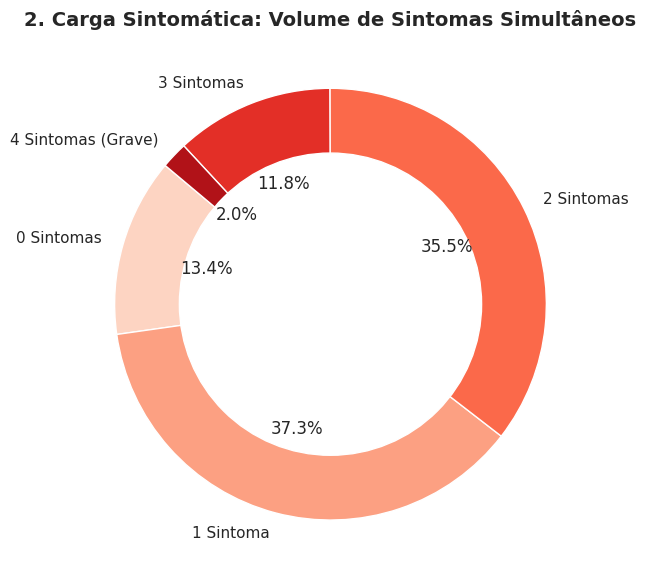

In [ ]:
# ---------------------------------------------------------------------
# GRÁFICO 2: Carga Sintomática (Severidade)
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 6))

# Calculando quantos 'Sim' cada paciente respondeu simultaneamente
df_base['carga_sintomatica'] = (df_base[sintomas_cols] == 'Sim').sum(axis=1)

# Categorizando para o gráfico
mapa_carga = {0: '0 Sintomas', 1: '1 Sintoma', 2: '2 Sintomas',
              3: '3 Sintomas', 4: '4 Sintomas (Grave)'}
df_base['desc_carga'] = df_base['carga_sintomatica'].map(mapa_carga)

df_carga = df_base.groupby('desc_carga')['pacientes_estimados'].sum().reset_index()

# Desenhando o Pie Chart
plt.pie(df_carga['pacientes_estimados'], labels=df_carga['desc_carga'], autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette("Reds", len(df_carga)))

# Transformando em Donut (desenhando um círculo branco por cima)
centro_branco = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_branco)

plt.title('2. Carga Sintomática: Volume de Sintomas Simultâneos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

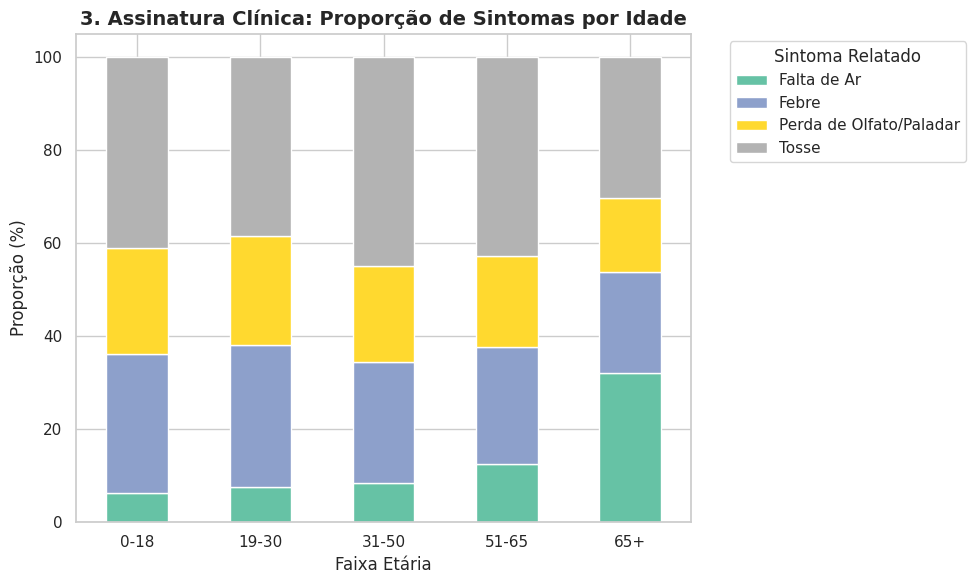

In [ ]:
# ---------------------------------------------------------------------
# GRÁFICO 3: Assinatura Clínica por Faixa Etária (100% Empilhado)
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Transformando colunas em linhas (Função Melt) para agrupar facilmente
df_melt = df_base.melt(id_vars=['faixa_etaria', 'pacientes_estimados'],
                       value_vars=sintomas_cols,
                       var_name='Sintoma', value_name='Resposta')

# Filtrando apenas respostas positivas
df_sim = df_melt[df_melt['Resposta'] == 'Sim'].copy()
df_sim['Sintoma'] = df_sim['Sintoma'].map(dict(zip(sintomas_cols, nomes_bonitos)))

# Agrupando e calculando os percentuais por idade
df_idade_sintoma = df_sim.groupby(['faixa_etaria', 'Sintoma'])['pacientes_estimados'].sum().unstack().fillna(0)
df_idade_pct = df_idade_sintoma.div(df_idade_sintoma.sum(axis=1), axis=0) * 100

# Ordenando as idades cronologicamente
ordem_idades = ['0-18', '19-30', '31-50', '51-65', '65+']
df_idade_pct = df_idade_pct.reindex(ordem_idades)

# Plotando
ax = df_idade_pct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10, 6))

plt.title('3. Assinatura Clínica: Proporção de Sintomas por Idade', fontsize=14, fontweight='bold')
plt.ylabel('Proporção (%)')
plt.xlabel('Faixa Etária')
plt.xticks(rotation=0)
plt.legend(title='Sintoma Relatado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_56606/3456167512.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


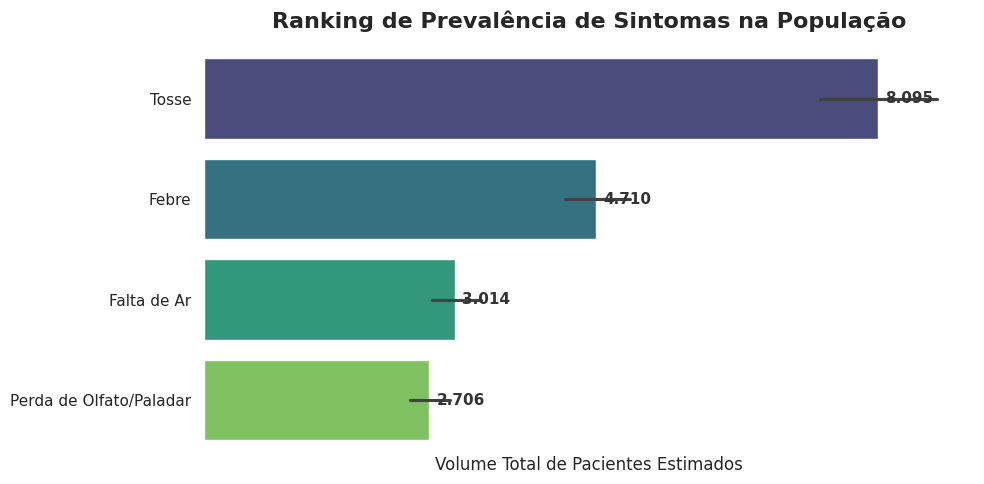

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. PREPARAÇÃO DOS DADOS (Simulando a Gold_Perfil_Sintomas)
# =====================================================================
# Quando for usar os dados reais, basta fazer:
# df_sintomas = pd.read_csv('seu_arquivo.csv')
dados_ficticios = {
    'nome_sintoma': ['Tosse', 'Febre', 'Falta de Ar', 'Perda de Olfato/Paladar'],
    'total_pacientes_estimados': [1250430, 850200, 320150, 210000]
}
df_sintomas = pd.read_csv('gold_perfil_sintomas.csv')

# Ordenar do maior para o menor para o gráfico ficar com formato de ranking
df_sintomas = df_sintomas.sort_values(by='total_pacientes_estimados', ascending=False)

# =====================================================================
# 2. DESENHANDO O GRÁFICO (Ranking de Prevalência)
# =====================================================================
# Configuração visual de fundo limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Criando o gráfico de barras horizontais com a paleta viridis
ax = sns.barplot(
    data=df_sintomas,
    x='total_pacientes_estimados',
    y='nome_sintoma',
    palette='viridis'
)

# Títulos e Eixos
plt.title('Ranking de Prevalência de Sintomas na População', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Volume Total de Pacientes Estimados', fontsize=12)
plt.ylabel('') # Deixamos vazio pois os nomes dos sintomas já são autoexplicativos

# O Pulo do Gato: Adicionando os rótulos de dados no final de cada barra
for p in ax.patches:
    width = p.get_width()
    # Formata o número com separador de milhares para facilitar a leitura da Diretoria
    texto_numero = f'{int(width):,}'.replace(',', '.')

    ax.annotate(texto_numero,
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points',
                fontsize=11, fontweight='bold', color='#333333')

# Remove a borda superior e direita para um visual mais limpo e moderno
sns.despine(left=True, bottom=True)
plt.xticks([]) # Esconde os números do eixo X no fundo, pois já temos os rótulos nas barras

plt.tight_layout()
plt.show()

/tmp/ipykernel_56606/886588670.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


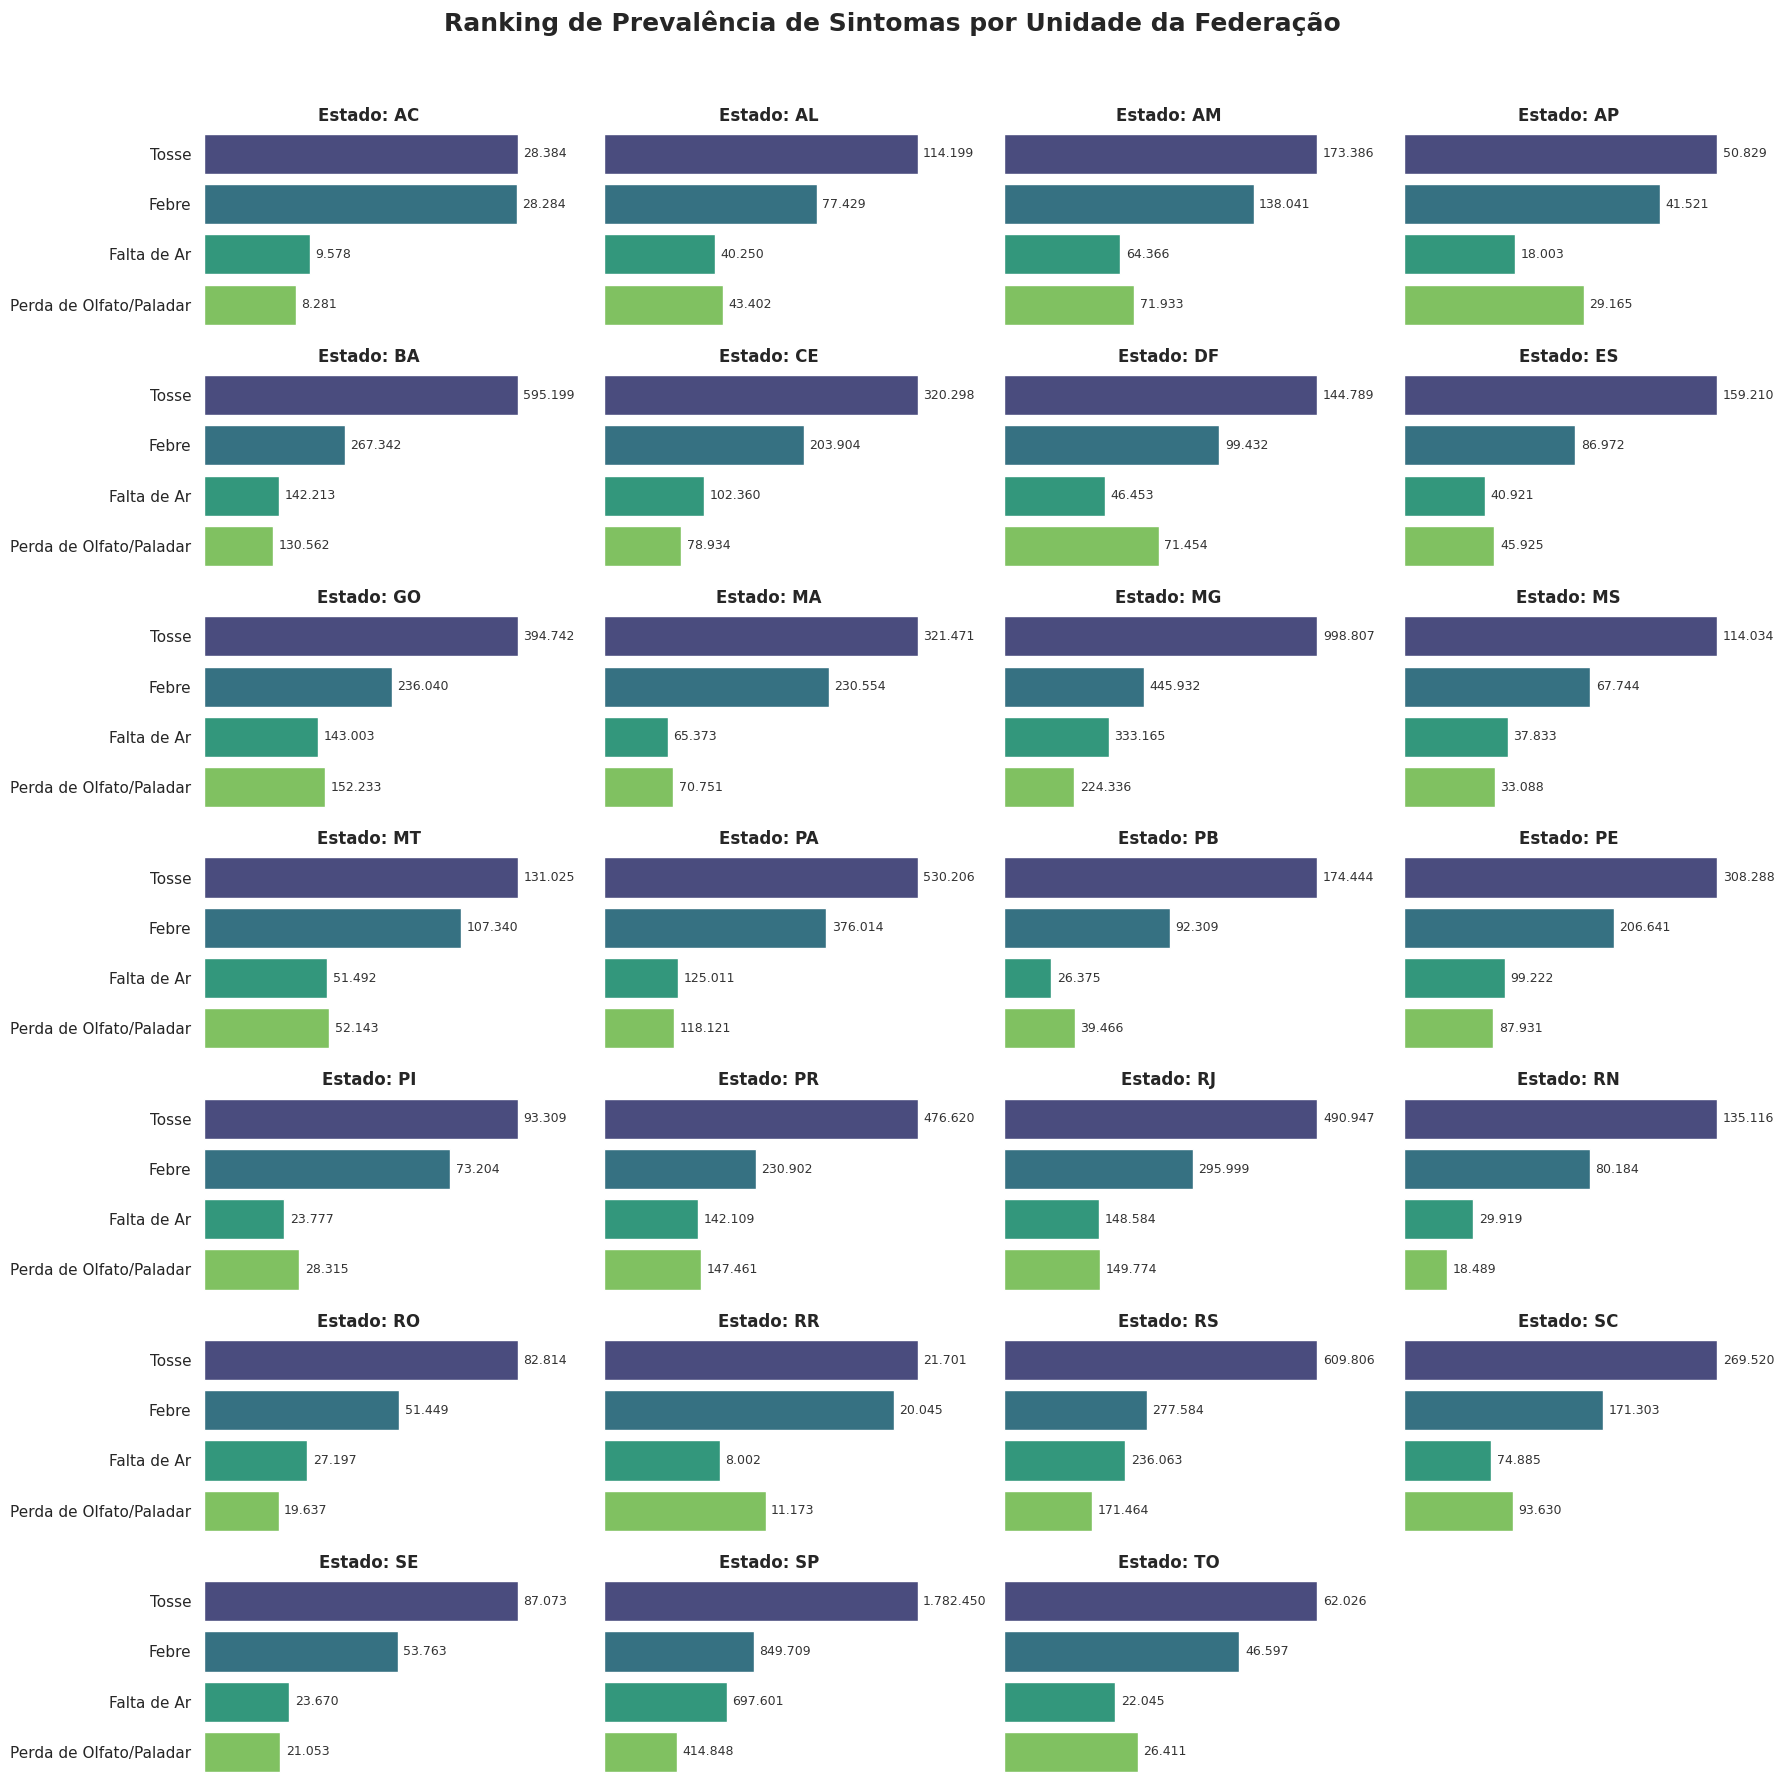

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =====================================================================
# 1. LEITURA E PREPARAÇÃO DOS DADOS REAIS
# =====================================================================
# Lê o arquivo que você fez o upload
df_real = pd.read_csv('gold_perfil_sintomas.csv')

# Extrai a UF de dentro dos parênteses da coluna 'polo_epidemiologico'
# O regex r'\((.*?)\)' significa: pegue tudo que está entre '(' e ')'
df_real['nome_uf'] = df_real['polo_epidemiologico'].str.extract(r'\((.*?)\)')

# Como a base tem outras aberturas (mês, faixa etária), precisamos agrupar
# os dados por UF e Sintoma, somando o total de pacientes
df_uf = df_real.groupby(['nome_uf', 'nome_sintoma'])['total_pacientes_estimados'].sum().reset_index()

# Ordem global dos sintomas para manter o padrão visual em todos os mini gráficos
ordem_sintomas = ['Tosse', 'Febre', 'Falta de Ar', 'Perda de Olfato/Paladar']

# =====================================================================
# 2. DESENHANDO OS MINI GRÁFICOS (Small Multiples por UF)
# =====================================================================
sns.set_theme(style="whitegrid")

# Criando a grade (Trellis)
g = sns.catplot(
    data=df_uf,
    x='total_pacientes_estimados',
    y='nome_sintoma',
    col='nome_uf',
    col_wrap=4,       # Ajustado para 4 colunas para acomodar bem os 27 estados na tela
    kind='bar',
    palette='viridis',
    order=ordem_sintomas,
    sharex=False,     # Mantém a escala independente para cada estado!
    height=2.5,       # Altura de cada bloquinho
    aspect=1.8        # Largura de cada bloquinho
)

# Ajustes de Títulos e Eixos
g.set_titles(col_template="Estado: {col_name}", size=12, fontweight='bold')
g.set_axis_labels("", "")

# Adicionando os rótulos de dados dinamicamente
for ax in g.axes.flat:
    for container in ax.containers:
        # Gera a formatação com ponto para separador de milhares em cada barra
        labels = [f'{int(val):,}'.replace(',', '.') if pd.notna(val) and val > 0 else '' for val in container.datavalues]
        ax.bar_label(container, labels=labels, padding=4, fontsize=9, color='#333333')

    # Limpando bordas desnecessárias
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.set_xticks([]) # Esconde o eixo X numérico, pois já temos os números nas barras

# Título Principal do Painel
g.figure.suptitle('Ranking de Prevalência de Sintomas por Unidade da Federação',
                  fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()